In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [41]:
df = pd.read_csv('IPL Matches 2008-2020.csv')

In [42]:
df.sample(5)

,id,city,date,player_of_match,venue,neutral_venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,eliminator,method,umpire1,umpire2
164,419155,Chennai,2010-04-15,G Gambhir,"MA Chidambaram Stadium, Chepauk",0,Chennai Super Kings,Delhi Daredevils,Chennai Super Kings,bat,Delhi Daredevils,wickets,6.0,N,NaN,HDPK Dharmasena,SS Hazare
199,501223,Delhi,2011-04-23,DA Warner,Feroz Shah Kotla,0,Delhi Daredevils,Kings XI Punjab,Kings XI Punjab,field,Delhi Daredevils,runs,29.0,N,NaN,S Asnani,RE Koertzen
788,1216524,Dubai,2020-10-27,WP Saha,Dubai International Cricket Stadium,0,Sunrisers Hyderabad,Delhi Capitals,Delhi Capitals,field,Sunrisers Hyderabad,runs,88.0,N,NaN,AK Chaudhary,Nitin Menon
741,1178421,Delhi,2019-04-28,S Dhawan,Feroz Shah Kotla,0,Delhi Capitals,Royal Challengers Bangalore,Delhi Capitals,bat,Delhi Capitals,runs,16.0,N,NaN,KN Ananthapadmanabhan,BNJ Oxenford
727,1178407,Chandigarh,2019-04-16,R Ashwin,"Punjab Cricket Association IS Bindra Stadium, ...",0,Kings XI Punjab,Rajasthan Royals,Rajasthan Royals,field,Kings XI Punjab,runs,12.0,N,NaN,VA Kulkarni,AK Chaudhary


In [87]:
df['date'] = pd.to_datetime(df['date'])

In [43]:
df.isnull().mean()*100

id                  0.000000
city                1.593137
date                0.000000
player_of_match     0.490196
venue               0.000000
neutral_venue       0.000000
team1               0.000000
team2               0.000000
toss_winner         0.000000
toss_decision       0.000000
winner              0.490196
result              0.490196
result_margin       2.083333
eliminator          0.490196
method             97.671569
umpire1             0.000000
umpire2             0.000000
dtype: float64

In [44]:
df = df.drop(columns=['eliminator','result','method','city','player_of_match','winner'])

In [45]:
df.isnull().mean()*100

id               0.000000
date             0.000000
venue            0.000000
neutral_venue    0.000000
team1            0.000000
team2            0.000000
toss_winner      0.000000
toss_decision    0.000000
result_margin    2.083333
umpire1          0.000000
umpire2          0.000000
dtype: float64

In [46]:
mean_result_margin = df['result_margin'].mean()
median_result_margin = df['result_margin'].median()

In [47]:
df['mean_result_margin'] = df['result_margin'].fillna(mean_result_margin)
df['median_result_margin'] = df['result_margin'].fillna(median_result_margin)

In [75]:
df.sample(5)

,id,date,venue,neutral_venue,team1,team2,toss_winner,toss_decision,result_margin,umpire1,umpire2,mean_result_margin,median_result_margin
484,829759,2015-04-27,"Punjab Cricket Association Stadium, Mohali",0,Kings XI Punjab,Sunrisers Hyderabad,Kings XI Punjab,field,20.0,HDPK Dharmasena,CB Gaffaney,20.000000,20.0
811,1216547,2020-09-28,Dubai International Cricket Stadium,0,Royal Challengers Bangalore,Mumbai Indians,Mumbai Indians,field,NaN,Nitin Menon,PR Reiffel,17.321652,8.0
345,598021,2013-04-19,"Rajiv Gandhi International Stadium, Uppal",0,Sunrisers Hyderabad,Kings XI Punjab,Kings XI Punjab,bat,5.0,HDPK Dharmasena,CK Nandan,5.000000,5.0
79,392204,2009-05-01,Kingsmead,1,Royal Challengers Bangalore,Kings XI Punjab,Royal Challengers Bangalore,bat,8.0,HDPK Dharmasena,S Ravi,8.000000,8.0
25,336007,2008-05-06,"MA Chidambaram Stadium, Chepauk",0,Chennai Super Kings,Deccan Chargers,Deccan Chargers,field,7.0,MR Benson,RB Tiffin,7.000000,7.0


In [77]:
print("original Result_Margin variance", df['result_margin'].var())
print("Result_Margin variance After Mean imputation", df['mean_result_margin'].var())
print("Result_Margin variance After Median imputation", df['median_result_margin'].var())

original Result_Margin variance 487.0154579188895
Result_Margin variance After Mean imputation 476.8568532751822
Result_Margin variance After Median imputation 478.63158907735095


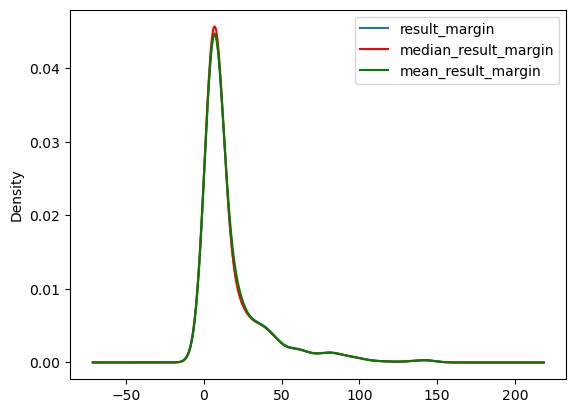

In [79]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution
df['result_margin'].plot(kind='kde', ax=ax)

# variable imputed with the median
df['median_result_margin'].plot(kind='kde', ax=ax, color='red')

# variable imputed with the mean
df['mean_result_margin'].plot(kind='kde', ax=ax, color='green')

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

<Axes: >

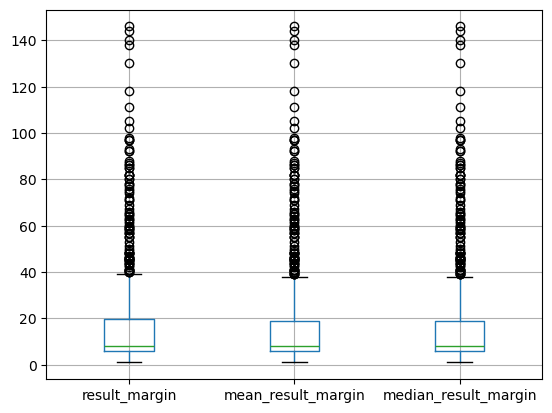

In [91]:
df[['result_margin','mean_result_margin','median_result_margin']].boxplot()

In [ ]:
# Using sklearn

In [92]:
imputer1 = SimpleImputer(strategy='mean')
imputer2 = SimpleImputer(strategy='median')

In [96]:
trf = ColumnTransformer([
    ('imputer1',imputer1,['result_margin']),
    ('imputer2',imputer2,['result_margin'])
],remainder='passthrough')

In [98]:
trf.fit(df)

transform_df = trf.transform(df)

In [99]:
trf.named_transformers_['imputer1'].statistics_

array([17.32165207])

In [100]:
trf.named_transformers_['imputer2'].statistics_

array([8.])